# ENTRENANDO MODELO DE ML PARA PREDECIR PRECIO DE AUTO USADO EN EUROPA
## DATASET: https://www.kaggle.com/datasets/alemazz11/cars-europe

# PASO 1 - INSTALAMOS E IMPORTAMOS LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set(style='whitegrid',context='notebook')

# PASO 2 CARGAMOS EL DATASET

In [3]:
df = pd.read_csv('/content/cars_cleaned.csv')
df

,Make,Model,Body,Mileage_km,Price,Year,Country,Condition,Fuel_Type,Fuel_Consumption_l,...,Cylinders,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners,Seller,Image_url
0,Abarth,595,Compact,98000,16900,2020.0,IT,Used,Gasoline,6.7,...,4.0,4.0,3.0,White,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
1,Abarth,595,Sedan,91500,12500,2017.0,IT,Used,Gasoline,6.0,...,4.0,4.0,3.0,Grey,Full leather,False,True,4.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
2,Abarth,595,Compact,40000,17990,2015.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Bronze,Full leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
3,Abarth,500,Compact,133000,9300,2008.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Black,Cloth,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
4,Abarth,595,Compact,61019,14990,2021.0,BE,Used,Gasoline,7.0,...,4.0,4.0,3.0,Yellow,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40489,Volvo,V60 Cross Country,Station wagon,73627,32990,2023.0,DE,Used,Diesel,7.0,...,5.0,5.0,5.0,Grey,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
40490,Volvo,XC60,Off-Road/Pick-up,93671,26990,2020.0,IT,Used,Electric/Diesel,7.0,...,4.0,5.0,5.0,Grey,Cloth,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
40491,Volvo,V90,Station wagon,60200,32490,2020.0,DE,Used,Gasoline,7.0,...,4.0,5.0,5.0,Black,Full leather,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
40492,Volvo,XC40,Off-Road/Pick-up,49088,29450,2022.0,NL,Used,Electric/Gasoline,7.0,...,3.0,5.0,5.0,Black,Cloth,True,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...


## PASO 3 - PREPROCESAMIENTO DE VARIABLES NÚMERICAS

In [4]:
df['Price'] = df['Price'] / 1000
df

,Make,Model,Body,Mileage_km,Price,Year,Country,Condition,Fuel_Type,Fuel_Consumption_l,...,Cylinders,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners,Seller,Image_url
0,Abarth,595,Compact,98000,16.90,2020.0,IT,Used,Gasoline,6.7,...,4.0,4.0,3.0,White,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
1,Abarth,595,Sedan,91500,12.50,2017.0,IT,Used,Gasoline,6.0,...,4.0,4.0,3.0,Grey,Full leather,False,True,4.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
2,Abarth,595,Compact,40000,17.99,2015.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Bronze,Full leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
3,Abarth,500,Compact,133000,9.30,2008.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Black,Cloth,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
4,Abarth,595,Compact,61019,14.99,2021.0,BE,Used,Gasoline,7.0,...,4.0,4.0,3.0,Yellow,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40489,Volvo,V60 Cross Country,Station wagon,73627,32.99,2023.0,DE,Used,Diesel,7.0,...,5.0,5.0,5.0,Grey,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
40490,Volvo,XC60,Off-Road/Pick-up,93671,26.99,2020.0,IT,Used,Electric/Diesel,7.0,...,4.0,5.0,5.0,Grey,Cloth,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
40491,Volvo,V90,Station wagon,60200,32.49,2020.0,DE,Used,Gasoline,7.0,...,4.0,5.0,5.0,Black,Full leather,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
40492,Volvo,XC40,Off-Road/Pick-up,49088,29.45,2022.0,NL,Used,Electric/Gasoline,7.0,...,3.0,5.0,5.0,Black,Cloth,True,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...


# SELECCIONAMOS COLUMNAS A UTILIZAR

In [5]:
df.columns

Index(['Make', 'Model', 'Body', 'Mileage_km', 'Price', 'Year', 'Country',
       'Condition', 'Fuel_Type', 'Fuel_Consumption_l', 'Drivetrain', 'Gearbox',
       'Gears', 'Power_hp', 'Engine_Size_cc', 'Cylinders', 'Seats', 'Doors',
       'Color', 'Upholstery', 'Full_Service_History', 'Non_Smoker_Vehicle',
       'Previous_Owners', 'Seller', 'Image_url'],
      dtype='object')

In [10]:
df['Upholstery'].value_counts()

,count
Upholstery,
Cloth,14877
Full leather,14657
Part leather,4576
Other,2329
alcantara,2014
Velour,248


In [7]:
df = df[df['Condition'] == 'Used']
df

,Make,Model,Body,Mileage_km,Price,Year,Country,Condition,Fuel_Type,Fuel_Consumption_l,...,Cylinders,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners,Seller,Image_url
0,Abarth,595,Compact,98000,16.90,2020.0,IT,Used,Gasoline,6.7,...,4.0,4.0,3.0,White,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
1,Abarth,595,Sedan,91500,12.50,2017.0,IT,Used,Gasoline,6.0,...,4.0,4.0,3.0,Grey,Full leather,False,True,4.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
2,Abarth,595,Compact,40000,17.99,2015.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Bronze,Full leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
3,Abarth,500,Compact,133000,9.30,2008.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Black,Cloth,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
4,Abarth,595,Compact,61019,14.99,2021.0,BE,Used,Gasoline,7.0,...,4.0,4.0,3.0,Yellow,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40489,Volvo,V60 Cross Country,Station wagon,73627,32.99,2023.0,DE,Used,Diesel,7.0,...,5.0,5.0,5.0,Grey,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
40490,Volvo,XC60,Off-Road/Pick-up,93671,26.99,2020.0,IT,Used,Electric/Diesel,7.0,...,4.0,5.0,5.0,Grey,Cloth,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
40491,Volvo,V90,Station wagon,60200,32.49,2020.0,DE,Used,Gasoline,7.0,...,4.0,5.0,5.0,Black,Full leather,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
40492,Volvo,XC40,Off-Road/Pick-up,49088,29.45,2022.0,NL,Used,Electric/Gasoline,7.0,...,3.0,5.0,5.0,Black,Cloth,True,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...


In [14]:
df = df[['Mileage_km', 'Price', 'Year', 'Fuel_Type', 'Fuel_Consumption_l', 'Drivetrain', 'Gearbox',
       'Gears', 'Power_hp', 'Engine_Size_cc', 'Cylinders', 'Seats', 'Doors', 'Full_Service_History', 'Non_Smoker_Vehicle',
       'Previous_Owners']]

In [15]:
df

,Mileage_km,Price,Year,Fuel_Type,Fuel_Consumption_l,Drivetrain,Gearbox,Gears,Power_hp,Engine_Size_cc,Cylinders,Seats,Doors,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners
0,98000,16.90,2020.0,Gasoline,6.7,Front Wheel Drive,Automatic,6.0,179,1368.0,4.0,4.0,3.0,False,False,1.0
1,91500,12.50,2017.0,Gasoline,6.0,Front Wheel Drive,Manual,5.0,165,1368.0,4.0,4.0,3.0,False,True,4.0
2,40000,17.99,2015.0,Gasoline,6.5,Front Wheel Drive,Manual,5.0,300,1368.0,4.0,4.0,3.0,True,True,1.0
3,133000,9.30,2008.0,Gasoline,6.5,Front Wheel Drive,Manual,5.0,160,1368.0,4.0,4.0,3.0,True,True,2.0
4,61019,14.99,2021.0,Gasoline,7.0,Front Wheel Drive,Manual,6.0,145,1368.0,4.0,4.0,3.0,True,True,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40489,73627,32.99,2023.0,Diesel,7.0,4WD,Automatic,6.0,197,1969.0,5.0,5.0,5.0,True,True,1.0
40490,93671,26.99,2020.0,Electric/Diesel,7.0,4WD,Automatic,8.0,197,1969.0,4.0,5.0,5.0,False,False,1.0
40491,60200,32.49,2020.0,Gasoline,7.0,Front Wheel Drive,Automatic,8.0,190,1969.0,4.0,5.0,5.0,True,True,2.0
40492,49088,29.45,2022.0,Electric/Gasoline,7.0,Front Wheel Drive,Automatic,7.0,211,1477.0,3.0,5.0,5.0,True,False,1.0


# PASO 4: CODIFICACIÓN DE VARIABLES CATEGORICAS CON SKLEARN

## 4.1 IDENTIFICAMOS VARIABLES CATEGORICAS

In [16]:
categorical_columns = df.select_dtypes(object).columns
categorical_columns

Index(['Fuel_Type', 'Drivetrain', 'Gearbox'], dtype='object')

In [18]:
df['Fuel_Type'] = df['Fuel_Type'].apply(lambda x: 'Gasoline' if x == 'Gasoline' else 'Other')
print(df['Fuel_Type'].value_counts())

Fuel_Type
Gasoline    21631
Other       17070
Name: count, dtype: int64


/tmp/ipython-input-1279295902.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fuel_Type'] = df['Fuel_Type'].apply(lambda x: 'Gasoline' if x == 'Gasoline' else 'Other')


## 4.2 CREAMOS LISTA POR TIPO DE CODIFICACIÓN

In [19]:
for cc in categorical_columns:
  print("*"*50)
  print(df[cc].value_counts())

**************************************************
Fuel_Type
Gasoline    21631
Other       17070
Name: count, dtype: int64
**************************************************
Drivetrain
Front Wheel Drive    20695
4WD                  10665
Rear Wheel Drive      7341
Name: count, dtype: int64
**************************************************
Gearbox
Automatic         24202
Manual            13762
Semi-automatic      737
Name: count, dtype: int64


In [20]:
ordinal_cols = ['Fuel_Type']
onehot_cols = list(set(categorical_columns) - set(ordinal_cols))
print(ordinal_cols,onehot_cols)

['Fuel_Type'] ['Drivetrain', 'Gearbox']


## 4.4 CODIFICAMOS USANDO LOS MODULSO COMPOSE Y PREPROCESSING DE SKLEARN

In [21]:
import sklearn.compose
import sklearn.preprocessing

### 4.4.1 CREAMOS UN TRANSFORMER

In [22]:
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(),ordinal_cols),
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinalencoder', OrdinalEncoder(),
                                 ['Fuel_Type']),
                                ('onehotencoder', OneHotEncoder(),
                                 ['Drivetrain', 'Gearbox'])])

### 4.4.2 APLICAMOS EL TRANSFOMER A EL DATASET

In [28]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df),
        columns = transformer.get_feature_names_out(),
        index=df.index
    )
)
data_transformed_df

,ordinalencoder__Fuel_Type,onehotencoder__Drivetrain_4WD,onehotencoder__Drivetrain_Front Wheel Drive,onehotencoder__Drivetrain_Rear Wheel Drive,onehotencoder__Gearbox_Automatic,onehotencoder__Gearbox_Manual,onehotencoder__Gearbox_Semi-automatic,remainder__Mileage_km,remainder__Price,remainder__Year,remainder__Fuel_Consumption_l,remainder__Gears,remainder__Power_hp,remainder__Engine_Size_cc,remainder__Cylinders,remainder__Seats,remainder__Doors,remainder__Full_Service_History,remainder__Non_Smoker_Vehicle,remainder__Previous_Owners
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,98000,16.9,2020.0,6.7,6.0,179,1368.0,4.0,4.0,3.0,False,False,1.0
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,91500,12.5,2017.0,6.0,5.0,165,1368.0,4.0,4.0,3.0,False,True,4.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,40000,17.99,2015.0,6.5,5.0,300,1368.0,4.0,4.0,3.0,True,True,1.0
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,133000,9.3,2008.0,6.5,5.0,160,1368.0,4.0,4.0,3.0,True,True,2.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,61019,14.99,2021.0,7.0,6.0,145,1368.0,4.0,4.0,3.0,True,True,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40489,1.0,1.0,0.0,0.0,1.0,0.0,0.0,73627,32.99,2023.0,7.0,6.0,197,1969.0,5.0,5.0,5.0,True,True,1.0
40490,1.0,1.0,0.0,0.0,1.0,0.0,0.0,93671,26.99,2020.0,7.0,8.0,197,1969.0,4.0,5.0,5.0,False,False,1.0
40491,0.0,0.0,1.0,0.0,1.0,0.0,0.0,60200,32.49,2020.0,7.0,8.0,190,1969.0,4.0,5.0,5.0,True,True,2.0
40492,1.0,0.0,1.0,0.0,1.0,0.0,0.0,49088,29.45,2022.0,7.0,7.0,211,1477.0,3.0,5.0,5.0,True,False,1.0


In [29]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,Fuel_Type,Drivetrain_4WD,Drivetrain_Front Wheel Drive,Drivetrain_Rear Wheel Drive,Gearbox_Automatic,Gearbox_Manual,Gearbox_Semi-automatic,Mileage_km,Price,Year,Fuel_Consumption_l,Gears,Power_hp,Engine_Size_cc,Cylinders,Seats,Doors,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,98000,16.9,2020.0,6.7,6.0,179,1368.0,4.0,4.0,3.0,False,False,1.0
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,91500,12.5,2017.0,6.0,5.0,165,1368.0,4.0,4.0,3.0,False,True,4.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,40000,17.99,2015.0,6.5,5.0,300,1368.0,4.0,4.0,3.0,True,True,1.0
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,133000,9.3,2008.0,6.5,5.0,160,1368.0,4.0,4.0,3.0,True,True,2.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,61019,14.99,2021.0,7.0,6.0,145,1368.0,4.0,4.0,3.0,True,True,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40489,1.0,1.0,0.0,0.0,1.0,0.0,0.0,73627,32.99,2023.0,7.0,6.0,197,1969.0,5.0,5.0,5.0,True,True,1.0
40490,1.0,1.0,0.0,0.0,1.0,0.0,0.0,93671,26.99,2020.0,7.0,8.0,197,1969.0,4.0,5.0,5.0,False,False,1.0
40491,0.0,0.0,1.0,0.0,1.0,0.0,0.0,60200,32.49,2020.0,7.0,8.0,190,1969.0,4.0,5.0,5.0,True,True,2.0
40492,1.0,0.0,1.0,0.0,1.0,0.0,0.0,49088,29.45,2022.0,7.0,7.0,211,1477.0,3.0,5.0,5.0,True,False,1.0


In [30]:
data_transformed_df.dtypes

,0
Fuel_Type,object
Drivetrain_4WD,object
Drivetrain_Front Wheel Drive,object
Drivetrain_Rear Wheel Drive,object
Gearbox_Automatic,object
Gearbox_Manual,object
Gearbox_Semi-automatic,object
Mileage_km,object
Price,object
Year,object


In [31]:
data_transformed_df = data_transformed_df.astype('float64')
data_transformed_df.dtypes

,0
Fuel_Type,float64
Drivetrain_4WD,float64
Drivetrain_Front Wheel Drive,float64
Drivetrain_Rear Wheel Drive,float64
Gearbox_Automatic,float64
Gearbox_Manual,float64
Gearbox_Semi-automatic,float64
Mileage_km,float64
Price,float64
Year,float64


In [32]:
data_transformed_df

,Fuel_Type,Drivetrain_4WD,Drivetrain_Front Wheel Drive,Drivetrain_Rear Wheel Drive,Gearbox_Automatic,Gearbox_Manual,Gearbox_Semi-automatic,Mileage_km,Price,Year,Fuel_Consumption_l,Gears,Power_hp,Engine_Size_cc,Cylinders,Seats,Doors,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,98000.0,16.90,2020.0,6.7,6.0,179.0,1368.0,4.0,4.0,3.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,91500.0,12.50,2017.0,6.0,5.0,165.0,1368.0,4.0,4.0,3.0,0.0,1.0,4.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,40000.0,17.99,2015.0,6.5,5.0,300.0,1368.0,4.0,4.0,3.0,1.0,1.0,1.0
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,133000.0,9.30,2008.0,6.5,5.0,160.0,1368.0,4.0,4.0,3.0,1.0,1.0,2.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,61019.0,14.99,2021.0,7.0,6.0,145.0,1368.0,4.0,4.0,3.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40489,1.0,1.0,0.0,0.0,1.0,0.0,0.0,73627.0,32.99,2023.0,7.0,6.0,197.0,1969.0,5.0,5.0,5.0,1.0,1.0,1.0
40490,1.0,1.0,0.0,0.0,1.0,0.0,0.0,93671.0,26.99,2020.0,7.0,8.0,197.0,1969.0,4.0,5.0,5.0,0.0,0.0,1.0
40491,0.0,0.0,1.0,0.0,1.0,0.0,0.0,60200.0,32.49,2020.0,7.0,8.0,190.0,1969.0,4.0,5.0,5.0,1.0,1.0,2.0
40492,1.0,0.0,1.0,0.0,1.0,0.0,0.0,49088.0,29.45,2022.0,7.0,7.0,211.0,1477.0,3.0,5.0,5.0,1.0,0.0,1.0


In [33]:
data_transformed_df.to_csv('cars_transformed.csv',index=None)

In [34]:
data_transformed_df = pd.read_csv('/content/cars_transformed.csv')
data_transformed_df

,Fuel_Type,Drivetrain_4WD,Drivetrain_Front Wheel Drive,Drivetrain_Rear Wheel Drive,Gearbox_Automatic,Gearbox_Manual,Gearbox_Semi-automatic,Mileage_km,Price,Year,Fuel_Consumption_l,Gears,Power_hp,Engine_Size_cc,Cylinders,Seats,Doors,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,98000.0,16.90,2020.0,6.7,6.0,179.0,1368.0,4.0,4.0,3.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,91500.0,12.50,2017.0,6.0,5.0,165.0,1368.0,4.0,4.0,3.0,0.0,1.0,4.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,40000.0,17.99,2015.0,6.5,5.0,300.0,1368.0,4.0,4.0,3.0,1.0,1.0,1.0
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,133000.0,9.30,2008.0,6.5,5.0,160.0,1368.0,4.0,4.0,3.0,1.0,1.0,2.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,61019.0,14.99,2021.0,7.0,6.0,145.0,1368.0,4.0,4.0,3.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38696,1.0,1.0,0.0,0.0,1.0,0.0,0.0,73627.0,32.99,2023.0,7.0,6.0,197.0,1969.0,5.0,5.0,5.0,1.0,1.0,1.0
38697,1.0,1.0,0.0,0.0,1.0,0.0,0.0,93671.0,26.99,2020.0,7.0,8.0,197.0,1969.0,4.0,5.0,5.0,0.0,0.0,1.0
38698,0.0,0.0,1.0,0.0,1.0,0.0,0.0,60200.0,32.49,2020.0,7.0,8.0,190.0,1969.0,4.0,5.0,5.0,1.0,1.0,2.0
38699,1.0,0.0,1.0,0.0,1.0,0.0,0.0,49088.0,29.45,2022.0,7.0,7.0,211.0,1477.0,3.0,5.0,5.0,1.0,0.0,1.0


# PASO 5 - CORRELACIONES

In [36]:
corr_matrix = data_transformed_df.corr()
corr_charges = corr_matrix['Price']
corr_charges.sort_values(ascending=False)

,Price
Price,1.000000
Power_hp,0.453386
Cylinders,0.335133
Engine_Size_cc,0.312425
Drivetrain_Rear Wheel Drive,0.178459
Fuel_Consumption_l,0.129001
Gearbox_Automatic,0.125601
Drivetrain_4WD,0.084853
Gears,0.084810
Gearbox_Semi-automatic,0.024095


<Axes: >

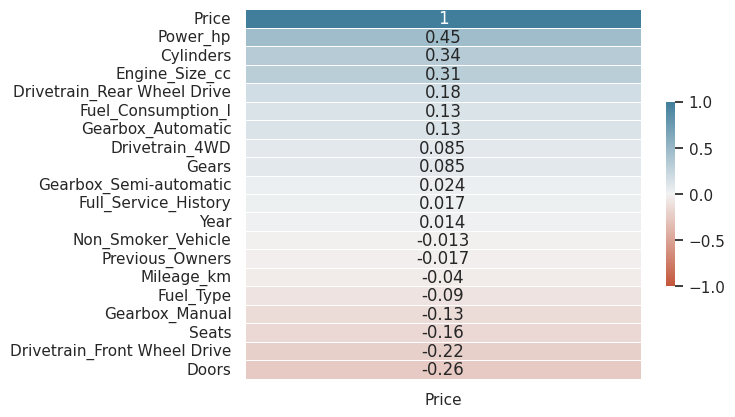

In [37]:
sns.heatmap(
    data=corr_charges.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

## PASO 6 - IDENTIFICAMOS VARIABLE X y Y , dividmos en train test

In [38]:
cols = corr_charges.index.tolist()
cols.remove('Price')
cols

['Fuel_Type',
 'Drivetrain_4WD',
 'Drivetrain_Front Wheel Drive',
 'Drivetrain_Rear Wheel Drive',
 'Gearbox_Automatic',
 'Gearbox_Manual',
 'Gearbox_Semi-automatic',
 'Mileage_km',
 'Year',
 'Fuel_Consumption_l',
 'Gears',
 'Power_hp',
 'Engine_Size_cc',
 'Cylinders',
 'Seats',
 'Doors',
 'Full_Service_History',
 'Non_Smoker_Vehicle',
 'Previous_Owners']

In [40]:
X = data_transformed_df[cols].values
y = data_transformed_df['Price'].values.reshape(-1,1)

In [41]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=42)

# CREAMOS UN CODIGO PARA PODER EVALUAR VARIOS MODELOS

## 1 - IMPORTAMOS LIBRERIAS

In [42]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler,MinMaxScaler

## 2 - ESCALAMIENTO DE DATOS

In [43]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

## 3 - CREAMOS DICCIONARIO DE MODELOS

In [44]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=0.1),
    "Ridge": Ridge(alpha=1.0),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=10),
    "SVR": SVR(kernel='rbf'),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

## 4 - CREAMOS BUCLE PARA PROBAR CADA MODELO DEL DICCIONARIO

In [45]:
results = {}
for name,model in models.items():

  model.fit(X_train_scaled,y_train_scaled.ravel())
  y_pred_scaled = model.predict(X_test_scaled)

  r2 = r2_score(y_test_scaled, y_pred_scaled)
  mse = mean_squared_error(y_test_scaled, y_pred_scaled)
  mae = mean_absolute_error(y_test_scaled, y_pred_scaled)
  results[name] = {"R2": r2, "MSE": mse, "MAE": mae}

# MOSTRAMOS RESULTADOS DE LOS MODELOS ENTRENADOS

In [46]:
results_df = pd.DataFrame(results).T
print("Model Comparison:")
display(results_df)

Model Comparison:


,R2,MSE,MAE
Linear Regression,0.219305,0.495663,0.215940
Lasso,0.268579,0.464379,0.180894
Ridge,0.219312,0.495659,0.215933
KNN Regressor,0.364118,0.403721,0.117527
SVR,0.413298,0.372497,0.102231
Random Forest Regressor,0.458505,0.343795,0.079550


# BUSCAMOS EL MEJOR MODELO

In [47]:
best_r2_model = results_df['R2'].idxmax()
best_mse_model = results_df['MSE'].idxmin()
print(f"\nBest model based on R2: {best_r2_model} (R2: {results_df.loc[best_r2_model, 'R2']:.4f})")
print(f"Best model based on MSE: {best_mse_model} (MSE: {results_df.loc[best_mse_model, 'MSE']:.2f})")


Best model based on R2: Random Forest Regressor (R2: 0.4585)
Best model based on MSE: Random Forest Regressor (MSE: 0.34)


# GRAFICAMOS RESULTADOS

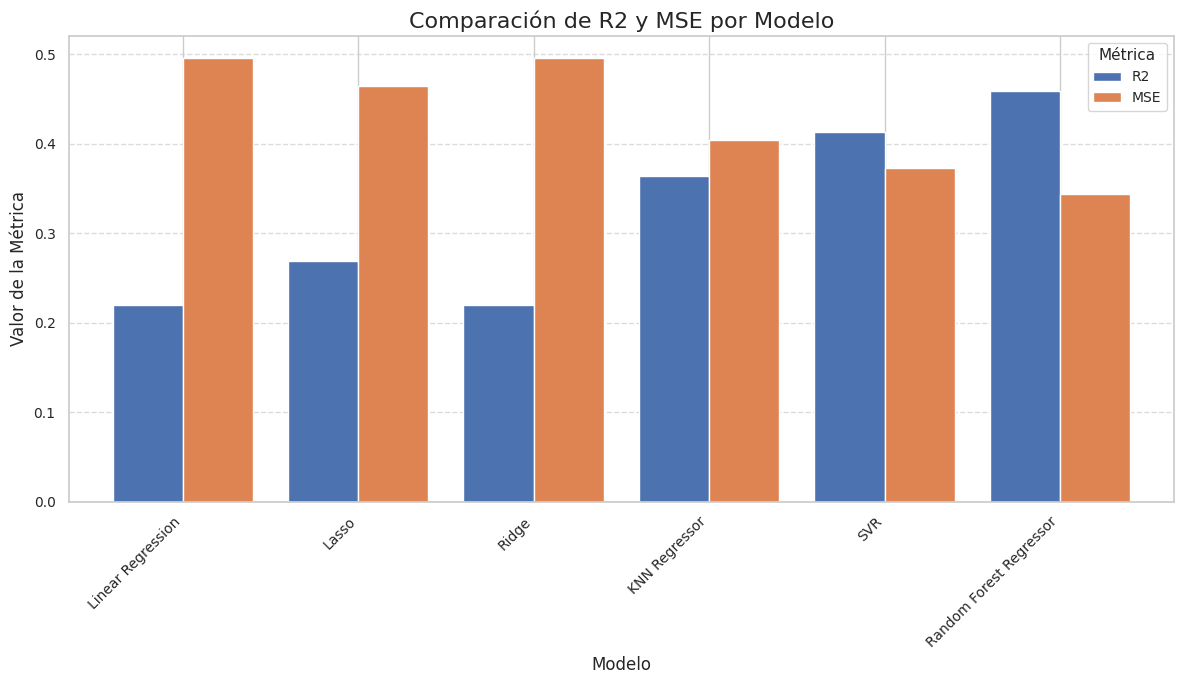

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las métricas R2 y MSE para comparar
results_to_plot = results_df[['R2', 'MSE']]

# Crear el gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(12, 7))
results_to_plot.plot(kind='bar', ax=ax, width=0.8)

plt.title('Comparación de R2 y MSE por Modelo', fontsize=16)
plt.ylabel('Valor de la Métrica', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Métrica', fontsize=10, title_fontsize='11')
plt.tight_layout()
plt.show()